In [1]:
import pandas as pd
import numpy as np
from astropy.io import fits
from astropy.table import Table
from astropy.stats import sigma_clip
import time
from scipy.stats import binned_statistic
import matplotlib.pyplot as plt

776 SNe before paper-based quality cuts.
579 SNe after paper-based quality cuts.


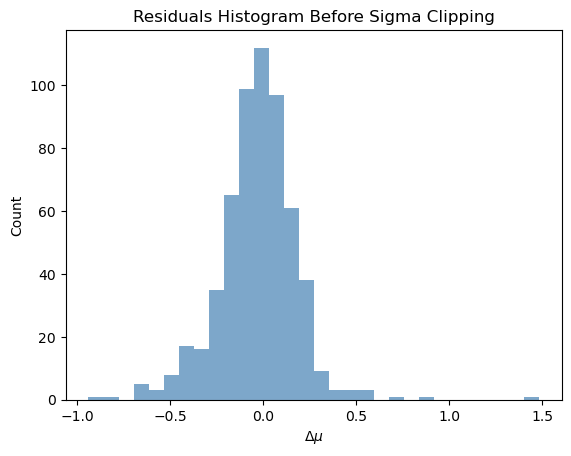

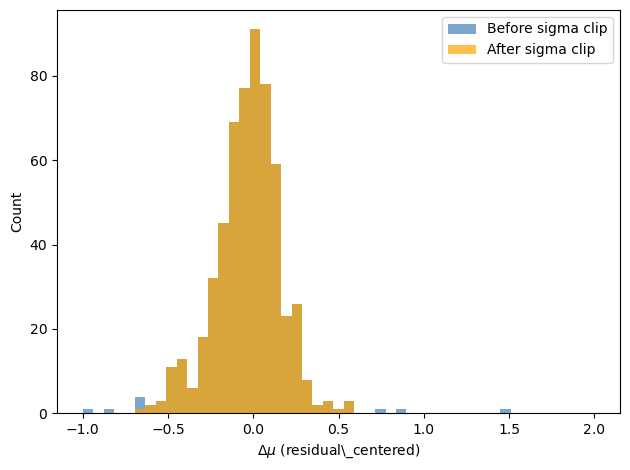

571 SNe after LOGMSTAR cut.
563 SNe after SFR cut.
571 SNe after VDISP cut.
569 SNe after DN4000 cut.
571 SNe after SDSS g-r cut.
568 SNe after AGE cut.


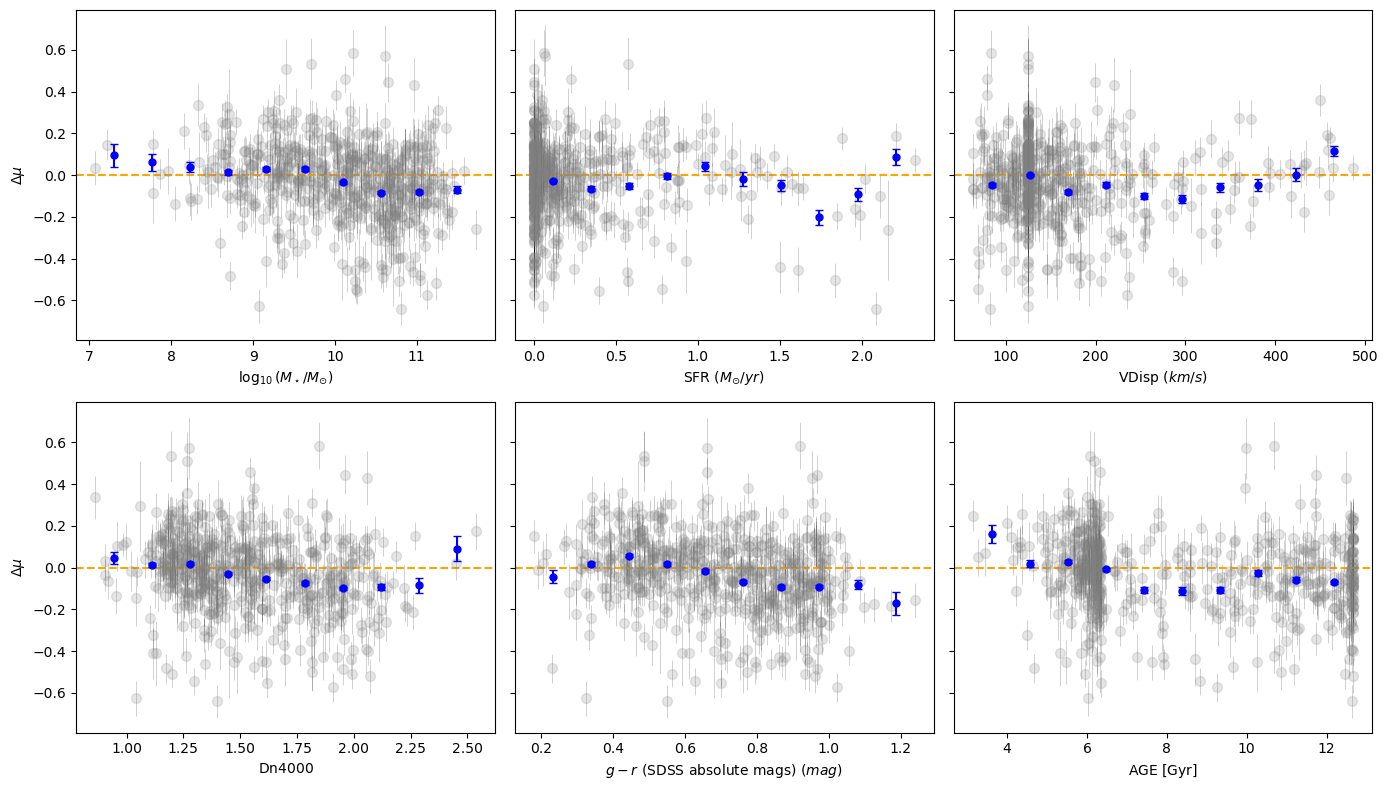

In [ ]:
df = pd.read_csv("ZTF_DESI_data/ZTF_resid_cent_hostprop_with_x1_c.csv")

# -----------------------------------------------------
# DATA FILTER - Paper lccoverage_flag and fitquality_flag
# -------------------------------------------------------
print(len(df), "SNe before paper-based quality cuts.")
df = df[(df["lccoverage_flag"] == 1) & (df["fitquality_flag"] == 1)]
print(len(df), "SNe after paper-based quality cuts.")

# --------------------------------------
# Create g - r host-galaxy color
# --------------------------------------
df["SDSS_g_minus_r"] = df["ABSMAG01_SDSS_G"] - df["ABSMAG01_SDSS_R"]


# -----------------------------
# GLOBAL sigma-clip on residuals 
# -----------------------------
# note: this only needs to get done once.
# We will be deleting the entries in the data frame. 

resid_before = df["residual_centered"]

# Plot histogram of residuals before sigma clipping
plt.hist(df["residual_centered"], bins=30, color="steelblue", alpha=0.7)
plt.xlabel(r"$\Delta \mu$")
plt.ylabel("Count")
plt.title("Residuals Histogram Before Sigma Clipping")
plt.show()

# drop all residuals that that are sigma clipped.
clip = sigma_clip(df["residual_centered"], sigma=3, maxiters=1)
mask_sigma = ~clip.mask  # True = keep
df = df.loc[mask_sigma].reset_index(drop=True)

resid_bins = np.linspace(-1, 2, 50)

# Plot histograms of residuals before and after sigma clipping
plt.figure(figsize=(10, 6))
plt.hist(resid_before, bins=resid_bins, label="Before sigma clip", alpha=0.7, color="steelblue")
plt.hist(df["residual_centered"], bins=resid_bins, label="After sigma clip", alpha=0.7, color="orange")

plt.xlabel(r"$\Delta \mu$ (residual_centered)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# Read the y-err collumn 
# -----------------------------
# note: this must be done only after the mu 
yerr_all = df["sigma_mu_meas"]



nbins = 10

# Helper funciton that plots the scatter and error bars. 
# ax - matplotlib axis where the plots will be drawn. 
# mask - the mask that selects which rows to use. 
# xcol - name of the df collumn to put on the x axis. Note residuals are always on the y-axis here.

def scatter_with_errors(ax, mask, xcol, nbins=None):
    # Raw values
    x = df.loc[mask, xcol].values
    y = df.loc[mask, "residual_centered"].values
    yerr = yerr_all.loc[mask].values

    # --- sigma clipping in y (vertical axis) ---
    # NOTE: sigma clipping has been moved OUTSIDE this function.
    # This function now assumes `mask` already includes whatever global sigma-clip
    # (or other cleaning) you want. In other words: this function only plots.

    # --- scatter cloud ---
    ax.scatter(x, y, **point_kwargs)

    # --- individual error bars ---
    # Important to note that the way that this function works we will be drawing
    # an error bar line from y - yerr to y + yerr. Where y_err = sigma_i
    ax.errorbar(
        x, y, yerr=yerr,
        fmt="none",
        ecolor="black",
        elinewidth=0.5,
        alpha=0.25,
        zorder=2,
    )

    # horizontal reference
    ax.axhline(0, linestyle="--", color="orange")

    # --- BINNING WITH ERROR PROPAGATION ---
    # NOTE: we set the number of bins here.

    # binned_statistic is a function tha takes (x, values, ststics, bins, range)
    # x - an array of positions along the x-axis.
    # values - the vaules on which the statistics are computed inside each bin.
    # NOTE: here we want to just count the number of points in each bin on the
    # horizontal axis of our plots. Therefore we parse "x" as both the argument and the
    # value and simply choose "count" as our statistics option.
    # bin_edges is an array of bin boundaries
    # binnumber - the index for which data point each bin belongs in.
    # This is done mostly becaue the data on the horizontal axis is not ranked so
    # we have to give it an identifier when we do our bin statistics later on.
    # Bin centers are just calcualted as the middle points between one bin edge and another.

    # Use nbins passed in (default to 10 if not provided)
    if nbins is None:
        nbins = 10

    _, bin_edges, binnumber = binned_statistic(x, x, statistic="count", bins=nbins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Creating arrays for ht residuals.
    binned_y = []
    binned_yerr = []

    # Just a fancy way of saying "for each bin"
    # We end up appending the data and error means into
    # an array.
    for i in range(1, len(bin_edges)):
        in_bin = binnumber == i

        # If a bin is empty, skip it (avoid divide-by-zero)
        if np.sum(in_bin) == 0:
            binned_y.append(np.nan)
            binned_yerr.append(np.nan)
            continue

        # We end up finding data and errro associated
        # with the number of bin that we are in.
        y_bin = y[in_bin]
        err_bin = yerr[in_bin]

        # inverse-variance weights
        w = 1.0 / (err_bin**2)

        # weighted mean
        y_mean = np.sum(w * y_bin) / np.sum(w)

        # propagated error on the mean
        err_mean = 1.0 / np.sqrt(np.sum(w))

        binned_y.append(y_mean)
        binned_yerr.append(err_mean)

    # Convert to arrays and only plot finite bins
    binned_y = np.array(binned_y)
    binned_yerr = np.array(binned_yerr)
    ok = np.isfinite(binned_y) & np.isfinite(binned_yerr)

    ax.errorbar(
        bin_centers[ok],
        binned_y[ok],
        yerr=binned_yerr[ok],
        fmt="o",
        color="blue",
        markersize=5,
        capsize=3,
        zorder=5  # Keeps the data looking on top
    )

# **************************************
# --------------------------------------
# Set up 2x3 grid - RESIDUALS + ERRORS + BINS w/t ERRORS
# --------------------------------------
# **************************************


fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=True)
axes = axes.flatten()

point_kwargs = dict(alpha=0.2, s=50, color="grey", zorder=3)   

# --------------------------------------
# 1) LOGMSTAR
# --------------------------------------
ax = axes[0]

# finite values mask (same as before)
mask_logm = np.ones(len(df), dtype=bool)
print(np.sum(mask_logm), "SNe after LOGMSTAR cut.")

# Use helper function with binning ON
scatter_with_errors(ax, mask_logm, "LOGMSTAR", nbins)

# Axis labels
ax.set_xlabel(r"$\log_{10}(M_\star / M_{\odot})$")
ax.set_ylabel(r"$\Delta \mu$")

# --------------------------------------
# 2) SFR (cut SFR > 2.5)
# --------------------------------------
ax = axes[1]

# Exclude SFR > 2.5
mask_sfr = (df["SFR"] <= 2.5)
print(np.sum(mask_sfr), "SNe after SFR cut.")

scatter_with_errors(ax, mask_sfr, "SFR", nbins=nbins)

ax.set_xlabel(r"${\rm SFR}\ (M_{\odot}/yr)$")

# --------------------------------------
# 3) VDISP
# --------------------------------------
ax = axes[2]

mask_vdisp = np.isfinite(df["VDISP"])
print(np.sum(mask_vdisp), "SNe after VDISP cut.")

scatter_with_errors(ax, mask_vdisp, "VDISP", nbins=nbins)

ax.set_xlabel(r"${\rm VDisp }\  (km/s) $")


# --------------------------------------
# 4) DN4000  (cut DN4000 < 0.5)
# --------------------------------------
ax = axes[3]

# keep only finite values AND DN4000 >= 0.5
mask_dn4000 = df["DN4000"] >= 0.5
print(np.sum(mask_dn4000), "SNe after DN4000 cut.")

scatter_with_errors(ax, mask_dn4000, "DN4000", nbins=nbins)

ax.set_xlabel(r"${\rm Dn4000}$")
ax.set_ylabel(r"$\Delta \mu$")


# --------------------------------------
# 5) SDSS g - r
# --------------------------------------
ax = axes[4]

mask_sdssq = np.isfinite(df["SDSS_g_minus_r"])
print(np.sum(mask_sdssq), "SNe after SDSS g-r cut.")

scatter_with_errors(ax, mask_sdssq, "SDSS_g_minus_r", nbins=nbins)

ax.set_xlabel(r"$g - r~{\rm (SDSS ~ absolute ~ mags)}\ (mag)$")


# --------------------------------------
# 6) AGE  (cut AGE < 2)
# --------------------------------------
ax = axes[5]

# keep only finite AGE and AGE >= 2
mask_age = df["AGE"] >= 2

print(np.sum(mask_age), "SNe after AGE cut.")

scatter_with_errors(ax, mask_age, "AGE", nbins=nbins)

ax.set_xlabel(r"${\rm AGE}\ [{\rm Gyr}]$")

# --------------------------------------
# Global cosmetics
# --------------------------------------

fig.tight_layout()
plt.show()
